In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('temperatures.csv')

In [3]:
df.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1901,22.40,24.14,29.07,31.91,33.41,33.18,31.21,30.39,30.47,29.97,27.31,24.49,28.96,23.27,31.46,31.27,27.25
1,1902,24.93,26.58,29.77,31.78,33.73,32.91,30.92,30.73,29.80,29.12,26.31,24.04,29.22,25.75,31.76,31.09,26.49
2,1903,23.44,25.03,27.83,31.39,32.91,33.00,31.34,29.98,29.85,29.04,26.08,23.65,28.47,24.24,30.71,30.92,26.26
3,1904,22.50,24.73,28.21,32.02,32.64,32.07,30.36,30.09,30.04,29.20,26.36,23.63,28.49,23.62,30.95,30.66,26.40
4,1905,22.00,22.83,26.68,30.01,33.32,33.25,31.44,30.68,30.12,30.67,27.52,23.82,28.30,22.25,30.00,31.33,26.57


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YEAR     117 non-null    int64  
 1   JAN      117 non-null    float64
 2   FEB      117 non-null    float64
 3   MAR      117 non-null    float64
 4   APR      117 non-null    float64
 5   MAY      117 non-null    float64
 6   JUN      117 non-null    float64
 7   JUL      117 non-null    float64
 8   AUG      117 non-null    float64
 9   SEP      117 non-null    float64
 10  OCT      117 non-null    float64
 11  NOV      117 non-null    float64
 12  DEC      117 non-null    float64
 13  ANNUAL   117 non-null    float64
 14  JAN-FEB  117 non-null    float64
 15  MAR-MAY  117 non-null    float64
 16  JUN-SEP  117 non-null    float64
 17  OCT-DEC  117 non-null    float64
dtypes: float64(17), int64(1)
memory usage: 16.6 KB


In [5]:
df.dtypes

YEAR         int64
JAN        float64
FEB        float64
MAR        float64
APR        float64
MAY        float64
JUN        float64
JUL        float64
AUG        float64
SEP        float64
OCT        float64
NOV        float64
DEC        float64
ANNUAL     float64
JAN-FEB    float64
MAR-MAY    float64
JUN-SEP    float64
OCT-DEC    float64
dtype: object

In [6]:
df.isnull().sum()

YEAR       0
JAN        0
FEB        0
MAR        0
APR        0
MAY        0
JUN        0
JUL        0
AUG        0
SEP        0
OCT        0
NOV        0
DEC        0
ANNUAL     0
JAN-FEB    0
MAR-MAY    0
JUN-SEP    0
OCT-DEC    0
dtype: int64

In [9]:
df.columns

Index(['YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
       'OCT', 'NOV', 'DEC', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP',
       'OCT-DEC'],
      dtype='object')

## seperate our data

In [11]:
## model 1 ,to predict month wise data
X = df[["YEAR"]]  # Predictor variable
y = df.drop(columns=["YEAR",'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP',
       'OCT-DEC'])

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
# Create and train the model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-Square: {r2:.2f}")



Mean Squared Error (MSE): 0.49
Mean Absolute Error (MAE): 0.50
R-Square: 0.29


In [21]:
y_pred

array([[23.51407809, 25.28171655, 28.83392001, 31.78293097, 33.44355703,
        32.61712887, 30.90326638, 30.32888333, 30.30947393, 29.5464574 ,
        27.06231118, 24.36468246],
       [23.03133884, 24.48230943, 28.2580577 , 31.27885792, 33.10878884,
        32.32710578, 30.60662559, 29.92001237, 29.87358186, 29.00579442,
        26.5160452 , 23.73933813],
       [23.62269442, 25.46158315, 28.96348903, 31.89634741, 33.51887987,
        32.68238407, 30.97001056, 30.42087929, 30.40754964, 29.66810658,
        27.18522102, 24.50538494],
       [23.48994113, 25.24174619, 28.80512689, 31.75772732, 33.42681862,
        32.60262772, 30.88843434, 30.30843978, 30.28767932, 29.51942425,
        27.03499788, 24.33341525],
       [23.10374972, 24.60222049, 28.34443705, 31.35446888, 33.15900406,
        32.37060925, 30.65112171, 29.98134301, 29.93896567, 29.08689387,
        26.59798509, 23.83313978],
       [24.00888582, 26.10110885, 29.42417888, 32.29960585, 33.78669443,
        32.91440254, 3

In [22]:
X.head()

,YEAR
0,1901
1,1902
2,1903
3,1904
4,1905


In [23]:
new = [[2024]]
model.predict(new)

C:\Users\krish\Projects\sample_project\env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[24.46748811, 26.86054562, 29.97124807, 32.77847524, 34.10472421,
        33.18992447, 31.48913195, 31.13640347, 31.17036076, 30.6142668 ,
        28.14118649, 25.59973752]])

'DEC'

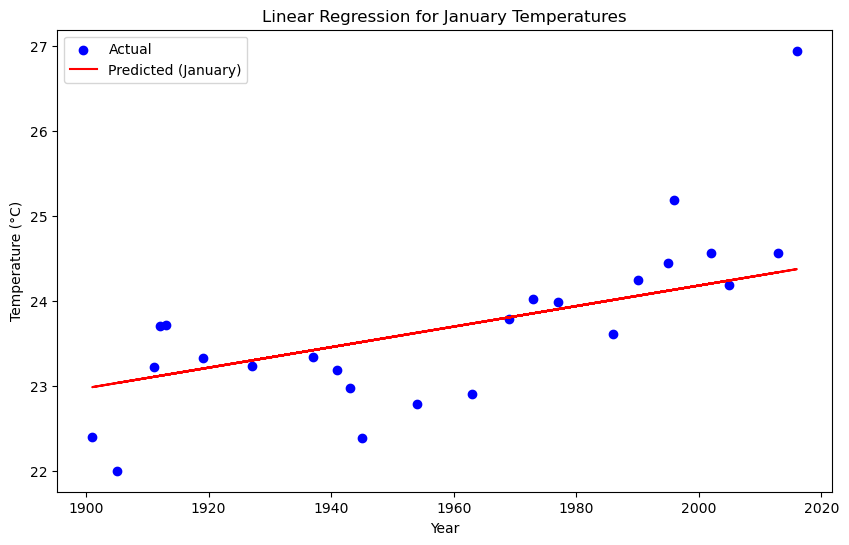

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test["JAN"], color="blue", label="Actual")
plt.plot(X_test, y_pred[:, 0], color="red", label="Predicted (January)")
plt.title("Linear Regression for January Temperatures")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()